In [28]:
import pandas as pd

In [29]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [31]:
def drpo_columns(df, columns):
    return df.drop(columns = columns)

In [32]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [33]:
from config import CAT

print(CAT)

['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']


In [34]:
def get_data_summary(df: pd.DataFrame)->pd.DataFrame:
    pd.DataFrame({"Dtype ": df.dtype, "n_unique" :df.n_unique}).T

In [35]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"null":null, "ratio" :ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [36]:
df = df.dropna(subset=['Embarked'])

In [37]:
df = df.drop('Cabin',axis=1)

In [38]:
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)

In [39]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"null ": null, "ratio ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
cols = ["Survived" , "Pclass", "Sex" , "SibSp","Parch" , "Embarked"]
df[cols] = df[cols].astype("category")
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,category,category,category,float64,category,category,float64,category


In [ ]:
num_col = df.select_dtypes("number").columns
num_col

Index(['Age', 'Fare'], dtype='str')

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

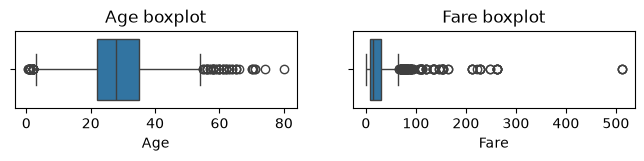

In [44]:
plt.figure(figsize=(8,1))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
    


In [45]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_fence, upper_fence)


In [46]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.000562,23.956061
std,12.051609,20.414997
min,2.500000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,54.500000,65.656300


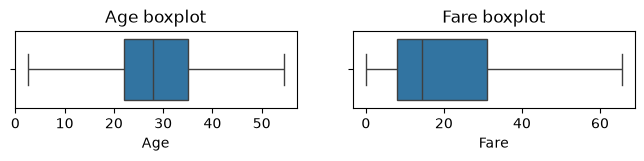

In [47]:
plt.figure(figsize=(8,1))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")


In [48]:
df.duplicated().sum()

np.int64(129)

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
def remove_duplicated(df, supset_cols = None, keep_strategy = "fisrt"):
    return df.drop_duplicates(supset_cols, keep = keep_strategy).reset_index(drop = True)

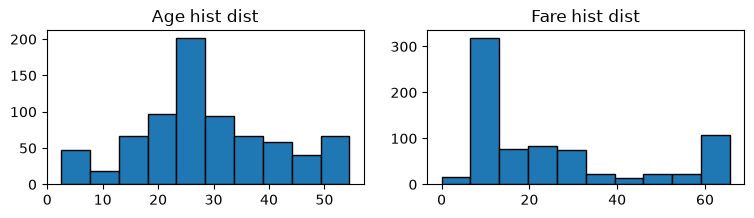

In [52]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist dist")

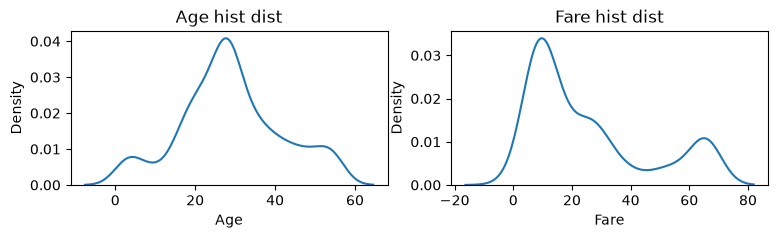

In [53]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist dist")

In [54]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

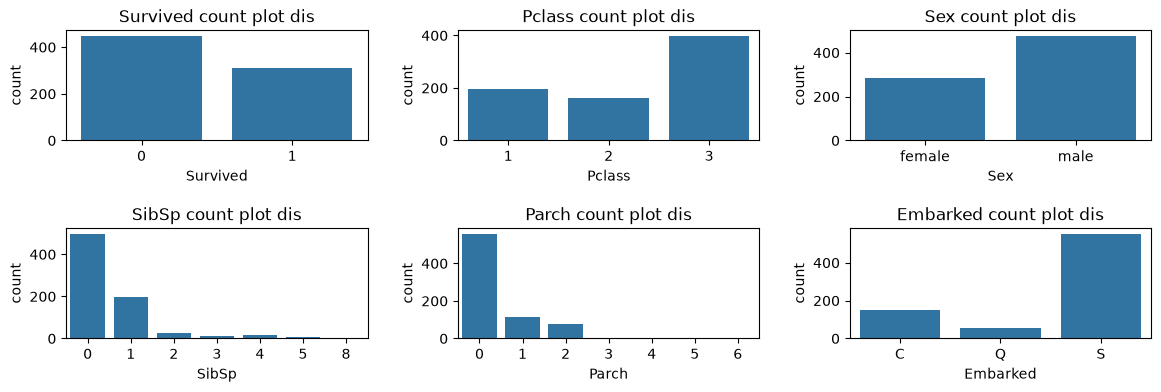

In [55]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2,3, i+1)
    sns.countplot(x = col, data=df)
    plt.title(f"{col} count plot dis")
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

In [56]:
unique = df["Survived"].value_counts()
count = unique.values
categories = unique.index

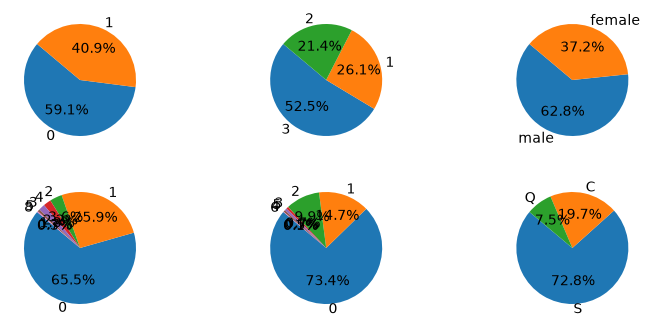

In [57]:
plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, startangle=140, autopct='%1.1f%%')

In [59]:
import plotly.express as px
fig = px.pie(df, names="Survived", color_discrete_sequence= px.colors.qualitative.Pastel, hole = 0.7)
fig.show()

Text(0, 0.5, 'Fare')

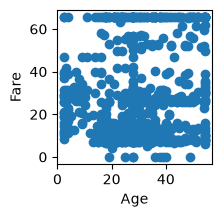

In [63]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

In [66]:
fig = px.scatter(df[num_col])
fig.show(render = "browser")